In [ ]:
"""
PIPELINE STAGE 5: Bayesian Latent Modeling & Downstream Regression for mismatched hallucination scores (z_i)
------------------------------------------------------------------
Role in Thesis:
    Aggregates the observation-level overlap metrics into an uncertainty-aware, 
    latent explainability score (z_i) using PyMC. Performs downstream regression 
    to evaluate Research Question 2 (Hypothesis 2): Does higher explainability 
    correlate with lower hallucination burden?
    
Diagnostics Checked:
    - Zero Divergences
    - Maximum R-hat value (acceptable around 1.0)
    - Posterior Predictive Checks (PPC) on transformed precision/recall features
"""


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Current working directory: /workspace/thesis/notebooks
DATAPATH: /workspace/thesis/outputs/radgraph_analysis_1500_subset/case_level_comparison.csv
Resolved DATAPATH: /workspace/thesis/outputs/radgraph_analysis_1500_subset/case_level_comparison.csv
Exists: True
Loaded shape: (272, 20)


,case_id,generated_report,reference_report,generated_observation_count,reference_observation_count,shared_observation_count,generated_only_count,reference_only_count,precision_obs,recall_obs,f1_obs,jaccard_obs,shared_observations,generated_only,reference_only,shared_rate_ref,generated_only_rate,reference_only_rate,mismatch_total,mismatch_rate_union
0,1041064153850317,AP and lateral views of the chest. There is a ...,Large right-sided pleural effusion with underl...,5,4,2,3,2,0.400000,0.50,0.444444,0.285714,large effusion; small effusion,mild congestion; pneumothorax; unchanged,atelectasis; consolidation,0.50,0.600000,0.50,5,0.714286
1,1102224550126222,Patient is status post median sternotomy and a...,Slight improvement in mild pulmonary edema. Pa...,13,4,3,10,1,0.230769,0.75,0.352941,0.214286,atelectasis; infection; patchy opacities,acute abnormalities; aspiration; large effusio...,slight improvement mild edema,0.75,0.769231,0.25,11,0.785714
2,1156909359234239,The ET tube is 5 cm above the carina. The NG t...,1. ET tube terminating 5.1 cm above the carina...,8,4,2,6,2,0.250000,0.50,0.333333,0.200000,elevation; et tube,effusion; haze; increased infiltrate; ng tube ...,orogastric tube; worsening mild - to - moderat...,0.50,0.750000,0.50,8,0.800000
3,1160762850790949,The endotracheal tube is 4.5 cm above the cari...,1. Endotracheal tube appropriately retracted t...,8,4,2,6,2,0.250000,0.50,0.333333,0.200000,edema; endotracheal tube,catheter; effusion; enteric tube tip; moderate...,mild cardiomegaly; moderate greater effusions,0.50,0.750000,0.50,8,0.800000
4,1188092357045176,The lungs are clear. The cardiomediastinal sil...,Tiny right pleural effusion.,4,2,1,3,1,0.250000,0.50,0.333333,0.200000,effusion,clear; normal; pneumothorax,tiny,0.50,0.750000,0.50,4,0.800000



=== model_A_reduced ===
Features: ['precision_obs', 'recall_obs']
Cases used for score model: 266


,precision_obs,recall_obs
count,266.000000,266.000000
mean,0.589708,0.977014
std,1.120809,1.986771
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,1.000000
max,6.400000,10.666667


Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [E, alpha, sigma_shared]


...

Sampling 4 chains for 5_000 tune and 4_000 draw iterations (20_000 + 16_000 draws total) took 306 seconds.
Sampling: [precision_obs_lik, recall_obs_lik]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[precision_obs],0.5617,0.0835,0.4095,0.7233,0.0011,0.0006,5392.2163,9112.7734,1.0005
alpha[recall_obs],0.9433,0.0839,0.7879,1.1019,0.0011,0.0006,5394.9699,9181.6449,1.0004
sigma_shared,0.9636,0.0433,0.8851,1.0477,0.0005,0.0003,6392.3466,9837.3779,1.0008


,case_id,explainability_score_mean,explainability_score_median
0,1189309153024166,3.969207,3.976331
1,1040237250879902,3.903876,3.911799
2,1218577550953777,3.619676,3.620692
3,1041064153850317,3.490837,3.497046
4,1102224550126222,3.481084,3.486340
5,1141323651499550,2.826017,2.828150
6,1188092357045176,2.677604,2.675527
7,1160762850790949,2.675562,2.676391
8,1156909359234239,2.674041,2.676693
9,1095905450128467,2.399051,2.401500


Max R-hat (score model main): 1.0
Min ESS bulk (score model main): 5392.0
Min ESS tail (score model main): 9113.0
Max R-hat (score model E): 1.0
Min ESS bulk (score model E): 11927.0
Min ESS tail (score model E): 9972.0


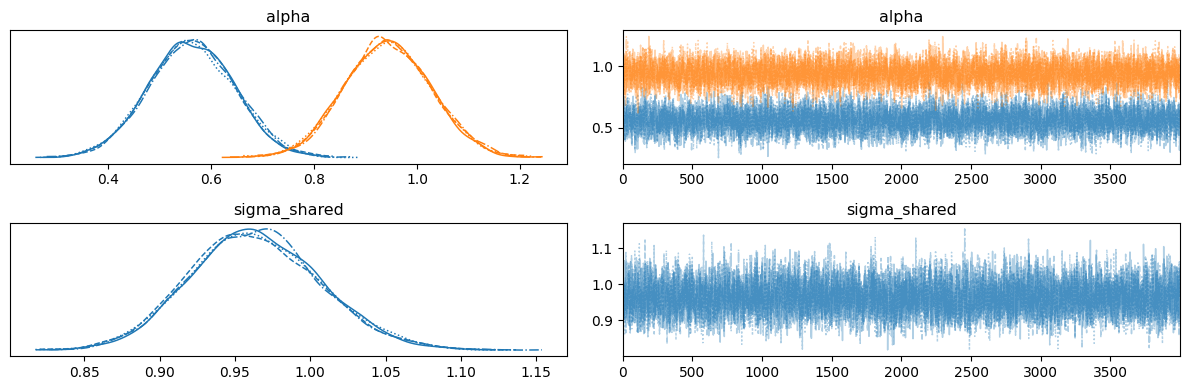

,feature,obs_mean,pp_mean_mean,pp_mean_p05,pp_mean_p95,obs_sd,pp_sd_mean,pp_sd_p05,pp_sd_p95,abs_mean_error,abs_sd_error,ppc_feature_error
0,precision_obs,0.589708,0.581942,0.446178,0.717631,1.118700,1.505333,1.407835,1.605558,0.007766,0.386634,0.394400
1,recall_obs,0.977014,0.962981,0.826881,1.099261,1.983033,1.504520,1.407441,1.602815,0.014033,0.478513,0.492546


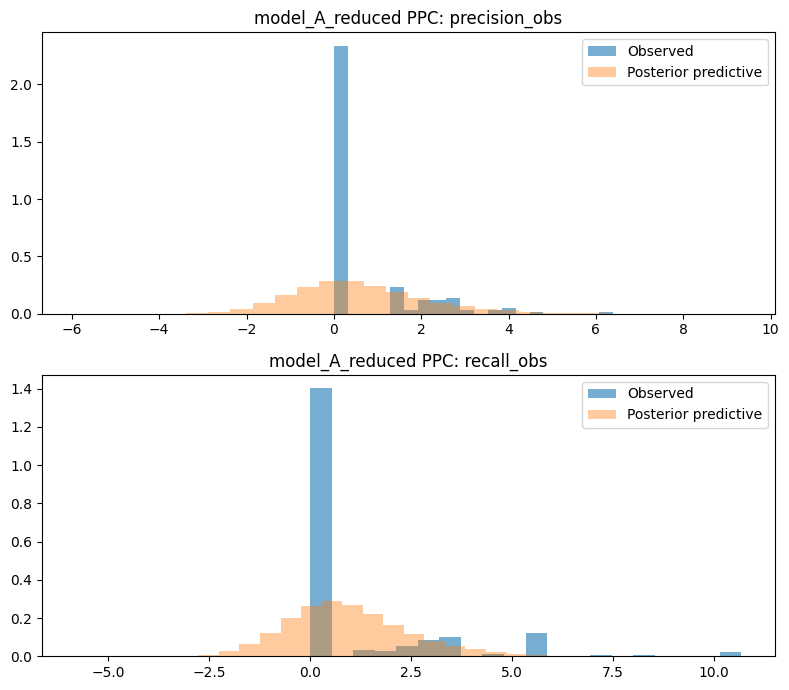

Initializing NUTS using adapt_diag...


Regression cases: 266
Score mean/std: -5.342426584662407e-17 0.9999999999999999
Hallucination mean/std: 1.1219095827791055e-15 0.9999999999999998


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma_h]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 39 seconds.
Sampling: [h_obs]


Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,0.0000,0.0239,-0.0439,0.0457,0.0003,0.0002,9148.1254,7029.6831,1.0003
beta1,-0.9183,0.0237,-0.9629,-0.8729,0.0003,0.0002,8656.9125,6867.1481,1.0006
sigma_h,0.3931,0.0174,0.3609,0.4256,0.0002,0.0002,8236.7399,7225.6905,1.0004


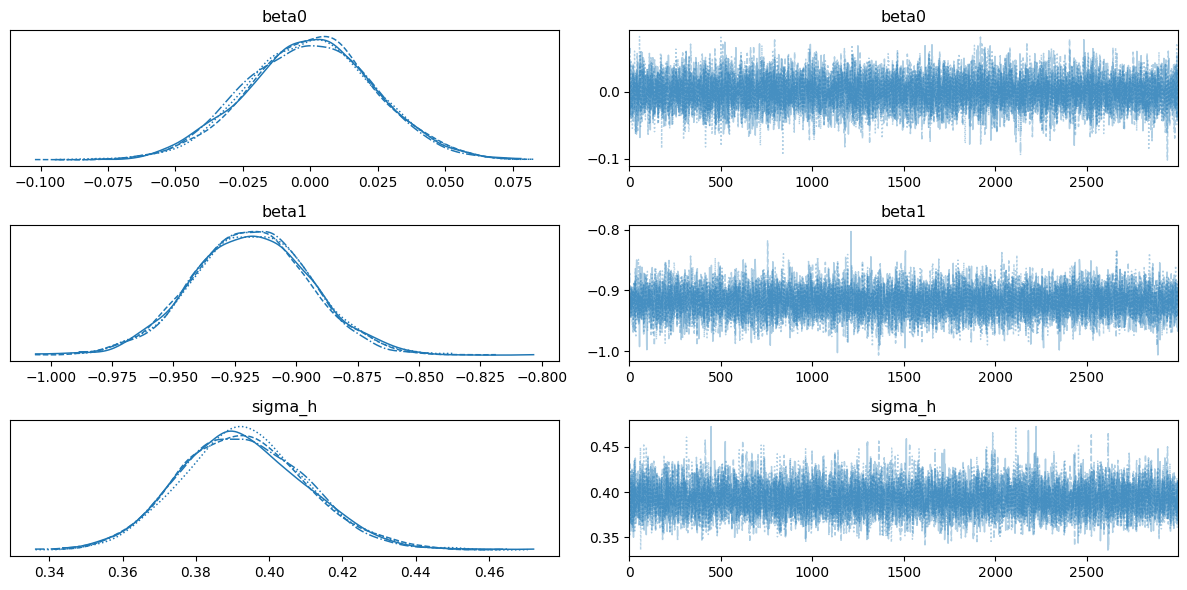

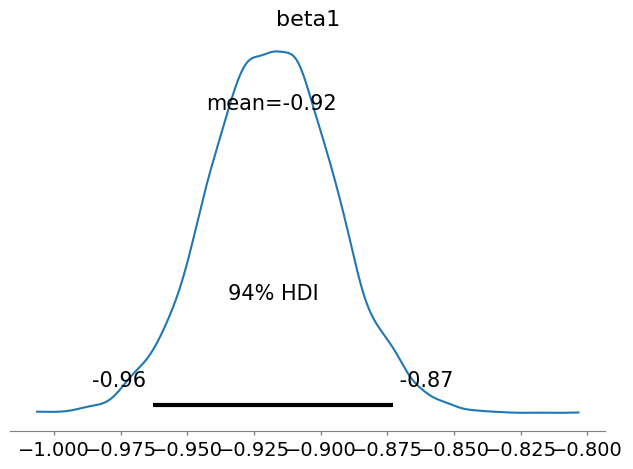

Posterior P(beta1 < 0): 1.0
Max R-hat (regression): 1.0
Min ESS bulk (regression): 8237.0
Min ESS tail (regression): 6867.0


,selected_model,observed_h_mean,observed_h_sd,pp_h_mean_mean,pp_h_mean_p05,pp_h_mean_p95,pp_h_sd_mean,pp_h_sd_p05,pp_h_sd_p95,posterior_prob_beta1_negative
0,model_A_reduced,1.121910e-15,1.0,-0.000428,-0.055753,0.055228,0.998699,0.946277,1.053521,1.0


,case_id,explainability_score_mean,explainability_score_median,score_group,selected_model
0,1189309153024166,3.969207,3.976331,top,model_A_reduced
1,1040237250879902,3.903876,3.911799,top,model_A_reduced
2,1218577550953777,3.619676,3.620692,top,model_A_reduced
3,1041064153850317,3.490837,3.497046,top,model_A_reduced
4,1102224550126222,3.481084,3.486340,top,model_A_reduced
5,1141323651499550,2.826017,2.828150,top,model_A_reduced
6,1188092357045176,2.677604,2.675527,top,model_A_reduced
7,1160762850790949,2.675562,2.676391,top,model_A_reduced
8,1156909359234239,2.674041,2.676693,top,model_A_reduced
9,1095905450128467,2.399051,2.401500,top,model_A_reduced


,selected_model,score_features,score_max_rhat_main,score_max_rhat_E,score_ppc_total_error,reg_beta1_mean,reg_beta1_median,reg_beta1_q05,reg_beta1_q95,posterior_prob_beta1_negative,reg_max_rhat,n_cases_score,n_cases_regression
0,model_A_reduced,"precision_obs, recall_obs",1.0,1.0,0.443473,-0.918347,-0.918401,-0.957184,-0.878873,1.0,1.0,266,266



Saved outputs to: /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A

Main files:
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/bayes_model_ready_features.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/score_model_posterior_summary.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/score_model_E_summary.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/score_model_diagnostics_overview.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/score_model_ppc_summary.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/case_explainability_scores.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/hallucination_regression_summary.csv
- /workspace/thesis/outputs/bayesian_explainability_1500_subset_reduced_model_A/hallucination_regression_p

In [ ]:
# =====================================================================
# ROBUST STANDARDIZATION
# =====================================================================
# Applies robust z-standardization (median/IQR) to precision and recall features 
# to keep extreme extraction outliers from distorting the PyMC likelihood space.

# =====================================================================
# BAYESIAN SCORE MODEL (LATENT EXPLAINABILITY E_i)
# =====================================================================
# Implements Eq. 3.12 from the thesis.
# Explainability is treated as a latent variable (E_i or z_i) that cannot be 
# observed directly. It is inferred probabilistically from imperfect indicators 
# (precision_obs and recall_obs).
# 
# - E: The unobserved Explainability score (latent space)
# - alpha: Feature-specific intercepts
# - sigma_shared: Residual variance not explained by E.

# =====================================================================
# DOWNSTREAM REGRESSION ANALYSIS (H2)
# =====================================================================
# Predicts hallucination burden (Hz) from the inferred explainability score (Sz).
# The parameter 'beta1' represents the substantive thesis outcome:
# A negative beta1 posterior indicates that higher structurally grounded 
# explainability corresponds to a lower rate of unsupported clinical findings.

# =====================================================================
# MCMC DIAGNOSTICS & POSTERIOR PREDICTIVE CHECKS
# =====================================================================
# Verifies model credibility per Gelman et al. / Vehtari et al.:
# - Extracts max R-hat (chain mixing parameter, acceptable around <= 1.02)
# - Validates lack of divergences.
# - Computes Posterior Predictive Checks (PPC) to ensure the transformed 
#   feature distributions are plausibly reproduced by the model.

import os
import sys

os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,optimizer_excluding=fusion")

!{sys.executable} -m pip install -q pymc arviz pandas numpy matplotlib

from pathlib import Path
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent
DATAPATH = PROJECT_ROOT / "outputs" / "radgraph_analysis_1500_subset" / "case_level_comparison.csv"
OUT = PROJECT_ROOT / "outputs" / "bayesian_explainability_1500_subset_reduced_model_A"
OUT.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("DATAPATH:", DATAPATH)
print("Resolved DATAPATH:", DATAPATH.resolve())
print("Exists:", DATAPATH.exists())

if not DATAPATH.exists():
    raise FileNotFoundError(f"Could not find {DATAPATH}")

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
# Reads the structured comparison outputs containing Observation-Level overlaps
# (Precision, Recall, Generated-Only). Renames columns for easier downstream modeling.
df = pd.read_csv(DATAPATH)

# renames columns to more convenient names for modeling and ensures numeric types for calculations.
rename_map = {
    "caseid": "case_id",
    "generatedobservationcount": "generated_observation_count",
    "referenceobservationcount": "reference_observation_count",
    "sharedobservationcount": "shared_observation_count",
    "generatedonlycount": "generated_only_count",
    "referenceonlycount": "reference_only_count",
    "precisionobs": "precision_obs",
    "recallobs": "recall_obs",
    "f1obs": "f1_obs",
    "jaccardobs": "jaccard_obs",
    "sharedrateref": "shared_rate_ref",
    "generatedonlyrate": "generated_only_rate",
    "referenceonlyrate": "reference_only_rate",
    "mismatchtotal": "mismatch_total",
    "mismatchrateunion": "mismatch_rate_union",
}
df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

numeric_cols = [
    "generated_observation_count",
    "reference_observation_count",
    "shared_observation_count",
    "generated_only_count",
    "reference_only_count",
    "precision_obs",
    "recall_obs",
    "f1_obs",
    "jaccard_obs",
    "shared_rate_ref",
    "generated_only_rate",
    "reference_only_rate",
    "mismatch_total",
    "mismatch_rate_union",
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Replace 0 with NaN to prevent division-by-zero errors when calculating rates and ratios. This ensures that cases with zero observations are handled gracefully in the modeling.
safe_gen = df["generated_observation_count"].replace(0, np.nan)
safe_ref = df["reference_observation_count"].replace(0, np.nan)
safe_union = (
    df["generated_only_count"]
    + df["reference_only_count"]
    + df["shared_observation_count"]
).replace(0, np.nan)

if "shared_rate_ref" not in df.columns:
    df["shared_rate_ref"] = df["shared_observation_count"] / safe_ref

if "generated_only_rate" not in df.columns:
    df["generated_only_rate"] = df["generated_only_count"] / safe_gen

if "reference_only_rate" not in df.columns:
    df["reference_only_rate"] = df["reference_only_count"] / safe_ref

if "mismatch_total" not in df.columns:
    df["mismatch_total"] = df["generated_only_count"] + df["reference_only_count"]

if "mismatch_rate_union" not in df.columns:
    df["mismatch_rate_union"] = df["mismatch_total"] / safe_union

model_ready = df.copy()
model_ready.to_csv(OUT / "bayes_model_ready_features.csv", index=False)

print("Loaded shape:", df.shape)
display(model_ready.head())

# ------------------------------------------------------------------
# Model A only
# ------------------------------------------------------------------
target_col = "generated_only_rate"
feature_cols = ["precision_obs", "recall_obs"]
model_label = "model_A_reduced"

# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------
def robust_z(s):
    med = s.median()
    iqr = s.quantile(0.75) - s.quantile(0.25)
    if pd.isna(iqr) or iqr == 0:
        return s - med
    return (s - med) / iqr

def build_workdf(df, feature_cols, target_col):
    cols = ["case_id"] + feature_cols + [target_col]
    return (
        df[cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )

def safe_corr(a, b):
    if len(a) < 2:
        return np.nan
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

def standard_z(a):
    a = np.asarray(a, dtype=float)
    s = a.std(ddof=0)
    if s == 0 or np.isnan(s):
        return a - a.mean()
    return (a - a.mean()) / s

# ------------------------------------------------------------------
# Score model
# ------------------------------------------------------------------
workdf = build_workdf(df, feature_cols, target_col)

X = workdf[feature_cols].copy()
# Apply robust z-standardization to prevent large outliers 
# in observation counts from dominating the PyMC scale metrics.
Xr = X.apply(robust_z)

composite_for_orientation = Xr.mean(axis=1).to_numpy()
n = len(workdf)

print(f"\n=== {model_label} ===")
print("Features:", feature_cols)
print("Cases used for score model:", n)
display(Xr.describe())

coords = {
    "case": np.arange(n),
    "feature": feature_cols,
}

with pm.Model(coords=coords) as score_model:
    # E_i: Latent Explainability Score per case (Conceptually Eq. 3.12)
    # Assumes explainability is unobserved but distributed normally across the cohort.
    E = pm.Normal("E", mu=0.0, sigma=1.0, dims="case")
    # alpha_j: Feature-specific intercepts
    alpha = pm.Normal("alpha", mu=0.0, sigma=0.5, dims="feature")
    # sigma_j: Residual variation not explained by the latent score E
    sigma_shared = pm.HalfNormal("sigma_shared", sigma=0.4)

    # Likelihood 1: Precision as an imperfect indicator of Explainability
    pm.Normal(
        "precision_obs_lik",
        mu=alpha[0] + E,
        sigma=sigma_shared,
        observed=Xr["precision_obs"].values,
        dims="case",
    )

    # Likelihood 2: Recall as an imperfect indicator of Explainability
    pm.Normal(
        "recall_obs_lik",
        mu=alpha[1] + E,
        sigma=sigma_shared,
        observed=Xr["recall_obs"].values,
        dims="case",
    )

    idata_score = pm.sample(
        draws=4000,
        tune=5000,
        chains=4,
        cores=4,
        init="adapt_diag",
        target_accept=0.99,
        max_treedepth=15,
        random_seed=42,
        return_inferencedata=True,
    )

    ppc = pm.sample_posterior_predictive(
        idata_score,
        var_names=["precision_obs_lik", "recall_obs_lik"],
        random_seed=42,
    )

idata_score.extend(ppc)

# ------------------------------------------------------------------
# Score summaries
# ------------------------------------------------------------------
score_summary = az.summary(
    idata_score,
    var_names=["alpha", "sigma_shared"],
    round_to=4,
)
score_summary.to_csv(OUT / "score_model_posterior_summary.csv")

score_summary_E = az.summary(
    idata_score,
    var_names=["E"],
    round_to=4,
)
score_summary_E.to_csv(OUT / "score_model_E_summary.csv")

score_mean_raw = idata_score.posterior["E"].mean(dim=("chain", "draw")).values
score_median_raw = idata_score.posterior["E"].median(dim=("chain", "draw")).values

corr = safe_corr(score_mean_raw, composite_for_orientation)
sign = 1.0 if np.isnan(corr) or corr >= 0 else -1.0

scores = workdf[["case_id"]].copy()
scores["explainability_score_mean"] = sign * score_mean_raw
scores["explainability_score_median"] = sign * score_median_raw
scores = scores.sort_values("explainability_score_mean", ascending=False).reset_index(drop=True)
scores.to_csv(OUT / "case_explainability_scores.csv", index=False)

display(score_summary)
display(scores.head(15))

# ------------------------------------------------------------------
# Score diagnostics
# ------------------------------------------------------------------
score_diag_main = az.summary(idata_score, var_names=["alpha", "sigma_shared"])
score_diag_E = az.summary(idata_score, var_names=["E"])

print("Max R-hat (score model main):", score_diag_main["r_hat"].max())
print("Min ESS bulk (score model main):", score_diag_main["ess_bulk"].min())
print("Min ESS tail (score model main):", score_diag_main["ess_tail"].min())
print("Max R-hat (score model E):", score_diag_E["r_hat"].max())
print("Min ESS bulk (score model E):", score_diag_E["ess_bulk"].min())
print("Min ESS tail (score model E):", score_diag_E["ess_tail"].min())

score_diag_overview = pd.DataFrame([{
    "selected_model": model_label,
    "max_rhat_main": float(score_diag_main["r_hat"].max()),
    "min_ess_bulk_main": float(score_diag_main["ess_bulk"].min()),
    "min_ess_tail_main": float(score_diag_main["ess_tail"].min()),
    "max_rhat_E": float(score_diag_E["r_hat"].max()),
    "min_ess_bulk_E": float(score_diag_E["ess_bulk"].min()),
    "min_ess_tail_E": float(score_diag_E["ess_tail"].min()),
}])
score_diag_overview.to_csv(OUT / "score_model_diagnostics_overview.csv", index=False)

az.plot_trace(idata_score, var_names=["alpha", "sigma_shared"])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Score PPC
# ------------------------------------------------------------------
ppc_rows = []
for feat in feature_cols:
    lik_name = f"{feat}_lik"
    obs = Xr[feat].values
    rep = idata_score.posterior_predictive[lik_name].values.reshape(-1, len(obs))

    rep_means = rep.mean(axis=1)
    rep_sds = rep.std(axis=1, ddof=0)

    ppc_rows.append({
        "feature": feat,
        "obs_mean": float(obs.mean()),
        "pp_mean_mean": float(rep_means.mean()),
        "pp_mean_p05": float(np.quantile(rep_means, 0.05)),
        "pp_mean_p95": float(np.quantile(rep_means, 0.95)),
        "obs_sd": float(obs.std(ddof=0)),
        "pp_sd_mean": float(rep_sds.mean()),
        "pp_sd_p05": float(np.quantile(rep_sds, 0.05)),
        "pp_sd_p95": float(np.quantile(rep_sds, 0.95)),
        "abs_mean_error": float(abs(obs.mean() - rep_means.mean())),
        "abs_sd_error": float(abs(obs.std(ddof=0) - rep_sds.mean())),
    })

ppc_summary = pd.DataFrame(ppc_rows)
ppc_summary["ppc_feature_error"] = ppc_summary["abs_mean_error"] + ppc_summary["abs_sd_error"]
ppc_summary.to_csv(OUT / "score_model_ppc_summary.csv", index=False)

display(ppc_summary)

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(8, 3.5 * len(feature_cols)))
if len(feature_cols) == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    lik_name = f"{feat}_lik"
    obs = Xr[feat].values
    rep = idata_score.posterior_predictive[lik_name].values.reshape(-1, len(obs)).flatten()
    ax.hist(obs, bins=20, alpha=0.6, density=True, label="Observed")
    ax.hist(rep, bins=30, alpha=0.4, density=True, label="Posterior predictive")
    ax.set_title(f"{model_label} PPC: {feat}")
    ax.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Regression
# ------------------------------------------------------------------
# We now merge the extracted explainability scores (Sz) to predict 
# the downstream target outcome: Hallucination/Generated-Only rate (Hz)

regdf = workdf.merge(
    scores[["case_id", "explainability_score_mean"]],
    on="case_id",
    how="left",
)

# Standardize values for the regression model
S = regdf["explainability_score_mean"].to_numpy()
Sz = standard_z(S)

H = regdf[target_col].to_numpy()
Hz = standard_z(H)

print("Regression cases:", len(regdf))
print("Score mean/std:", Sz.mean(), Sz.std(ddof=0))
print("Hallucination mean/std:", Hz.mean(), Hz.std(ddof=0))

with pm.Model() as hallucination_model:
    # Set weak priors for the regression predicting hallucination burden
    beta0 = pm.Normal("beta0", mu=0.0, sigma=0.5)
    beta1 = pm.Normal("beta1", mu=0.0, sigma=0.5)
    sigma_h = pm.HalfNormal("sigma_h", sigma=0.5)

    # Likelihood for predicting Hallucination (H_obs) purely from Latent Explainability (Sz)
    pm.Normal(
        "h_obs",
        mu=beta0 + beta1 * Sz,
        sigma=sigma_h,
        observed=Hz,
    )

    idata_reg = pm.sample(
        draws=3000,
        tune=3000,
        chains=4,
        cores=4,
        init="adapt_diag",
        target_accept=0.99,
        max_treedepth=15,
        random_seed=42,
        return_inferencedata=True,
    )

    ppc_reg = pm.sample_posterior_predictive(
        idata_reg,
        var_names=["h_obs"],
        random_seed=42,
    )

idata_reg.extend(ppc_reg)

reg_summary = az.summary(
    idata_reg,
    var_names=["beta0", "beta1", "sigma_h"],
    round_to=4,
)
reg_summary.to_csv(OUT / "hallucination_regression_summary.csv")

display(reg_summary)

az.plot_trace(idata_reg, var_names=["beta0", "beta1", "sigma_h"])
plt.tight_layout()
plt.show()

az.plot_posterior(idata_reg, var_names=["beta1"])
plt.tight_layout()
plt.show()

beta1_samples = idata_reg.posterior["beta1"].values.flatten()
prob_negative = float((beta1_samples < 0).mean())

print("Posterior P(beta1 < 0):", prob_negative)

reg_diag = az.summary(idata_reg, var_names=["beta0", "beta1", "sigma_h"])
print("Max R-hat (regression):", reg_diag["r_hat"].max())
print("Min ESS bulk (regression):", reg_diag["ess_bulk"].min())
print("Min ESS tail (regression):", reg_diag["ess_tail"].min())

rep_h = idata_reg.posterior_predictive["h_obs"].values.reshape(-1, len(Hz))
reg_ppc_summary = pd.DataFrame([{
    "selected_model": model_label,
    "observed_h_mean": float(Hz.mean()),
    "observed_h_sd": float(Hz.std(ddof=0)),
    "pp_h_mean_mean": float(rep_h.mean(axis=1).mean()),
    "pp_h_mean_p05": float(np.quantile(rep_h.mean(axis=1), 0.05)),
    "pp_h_mean_p95": float(np.quantile(rep_h.mean(axis=1), 0.95)),
    "pp_h_sd_mean": float(rep_h.std(axis=1, ddof=0).mean()),
    "pp_h_sd_p05": float(np.quantile(rep_h.std(axis=1, ddof=0), 0.05)),
    "pp_h_sd_p95": float(np.quantile(rep_h.std(axis=1, ddof=0), 0.95)),
    "posterior_prob_beta1_negative": prob_negative,
}])
reg_ppc_summary.to_csv(OUT / "hallucination_regression_ppc_summary.csv", index=False)

display(reg_ppc_summary)

# ------------------------------------------------------------------
# Qualitative cases
# ------------------------------------------------------------------
top_cases = scores.head(15).copy()
top_cases["score_group"] = "top"

bottom_cases = scores.tail(15).copy()
bottom_cases["score_group"] = "bottom"

qual_scores = pd.concat([top_cases, bottom_cases], ignore_index=True)
qual_scores["selected_model"] = model_label
qual_scores.to_csv(OUT / "qualitative_explainability_cases.csv", index=False)

display(qual_scores)

# ------------------------------------------------------------------
# Final overview
# ------------------------------------------------------------------
final_overview = pd.DataFrame([{
    "selected_model": model_label,
    "score_features": ", ".join(feature_cols),
    "score_max_rhat_main": float(score_diag_main["r_hat"].max()),
    "score_max_rhat_E": float(score_diag_E["r_hat"].max()),
    "score_ppc_total_error": float(ppc_summary["ppc_feature_error"].mean()),
    "reg_beta1_mean": float(beta1_samples.mean()),
    "reg_beta1_median": float(np.median(beta1_samples)),
    "reg_beta1_q05": float(np.quantile(beta1_samples, 0.05)),
    "reg_beta1_q95": float(np.quantile(beta1_samples, 0.95)),
    "posterior_prob_beta1_negative": prob_negative,
    "reg_max_rhat": float(reg_diag["r_hat"].max()),
    "n_cases_score": len(workdf),
    "n_cases_regression": len(regdf),
}])
final_overview.to_csv(OUT / "final_overview.csv", index=False)

display(final_overview)

print("\nSaved outputs to:", OUT.resolve())
print("\nMain files:")
print("-", OUT / "bayes_model_ready_features.csv")
print("-", OUT / "score_model_posterior_summary.csv")
print("-", OUT / "score_model_E_summary.csv")
print("-", OUT / "score_model_diagnostics_overview.csv")
print("-", OUT / "score_model_ppc_summary.csv")
print("-", OUT / "case_explainability_scores.csv")
print("-", OUT / "hallucination_regression_summary.csv")
print("-", OUT / "hallucination_regression_ppc_summary.csv")
print("-", OUT / "qualitative_explainability_cases.csv")
print("-", OUT / "final_overview.csv")
